Hello world

In [1]:
Hello world

<class 'SyntaxError'>: invalid syntax (<ipython-input-1-33ab5639bfd8>, line 1)

In [2]:
"Hello world"

'Hello world'

In [3]:
"Hello\nworld"

'Hello\nworld'

In [5]:
print("Hello\nworld")

Hello
world


In [6]:
print("Hello, world!")

Hello, world!


In [1]:
import requests
table_name = "const_vdv_pretty_with_mw_volume.tsv"
response = requests.get(
    "https://cdn.lazarev.fun/data/"
     + table_name
)

In [2]:
from pathlib import Path
vdv_table_path = Path(f"./{table_name}")
vdv_table_path.write_text(
    response.content.decode("utf-8")
)

1541

In [ ]:
from io import StringIO
df = pd.read_csv(
    StringIO(response.content.decode("utf-8")), 
    sep="\t"
)

In [3]:
import pandas as pd
df = pd.read_csv(vdv_table_path, sep="\t")
df.head(1);

In [4]:
%pip install seaborn

In [5]:
import seaborn

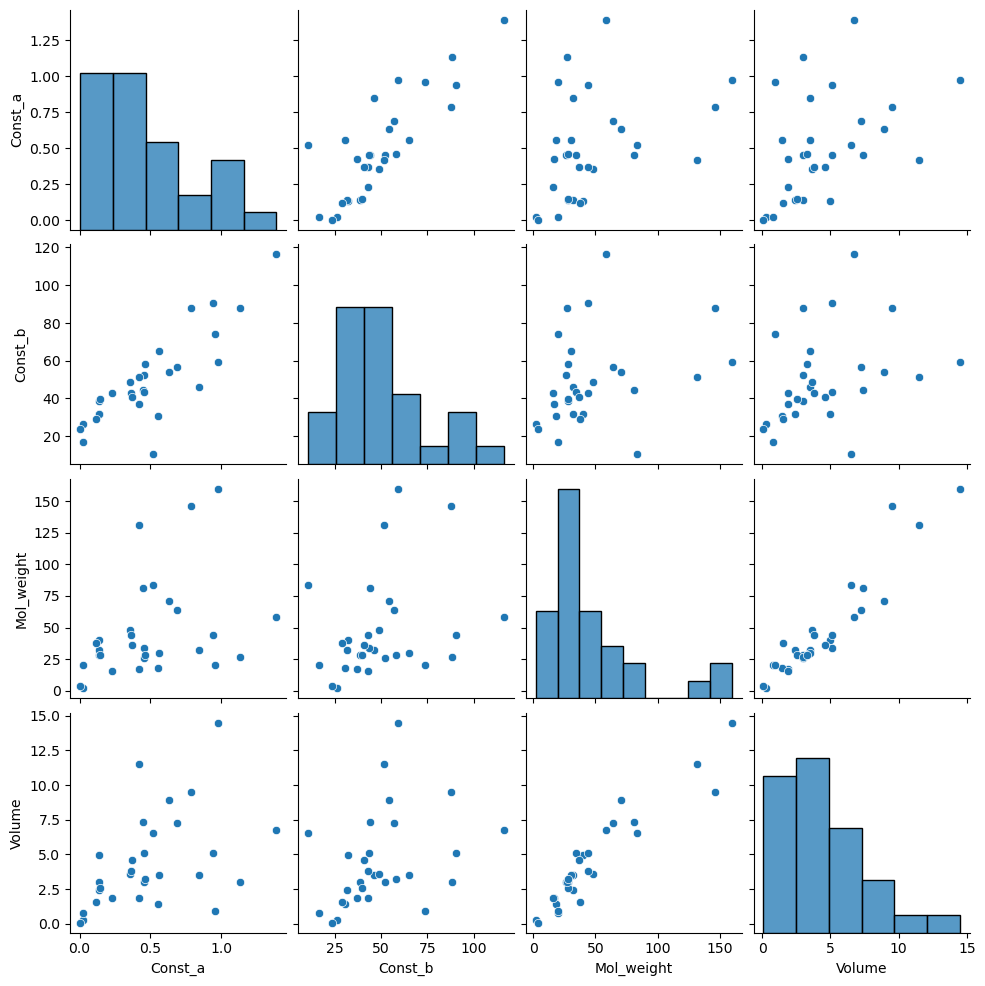

In [6]:
seaborn.pairplot(df)

<Axes: xlabel='Volume', ylabel='Mol_weight'>

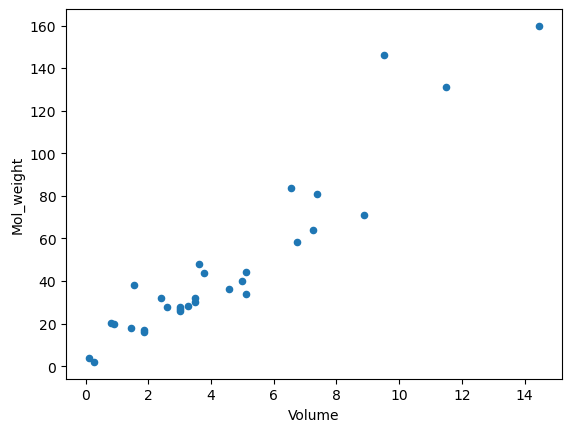

In [8]:
df.plot(x="Volume", y="Mol_weight", kind="scatter")

In [9]:
%pip install scikit-learn

In [11]:
from sklearn.linear_model import LinearRegression

In [13]:
reg = LinearRegression()
reg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
reg.fit(df[["Volume"]], df["Mol_weight"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
reg.coef_, reg.intercept_

(array([10.81328346]), np.float64(-0.8267534529862743))

In [18]:
df["Mol_weight_pred"] = (
    df.Volume * reg.coef_[0] + reg.intercept_
)
df.head(1)

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume,Mol_weight_pred
0,Азот,N2,0.137,38.7,28.014,2.998428,31.5961


<Axes: xlabel='Volume'>

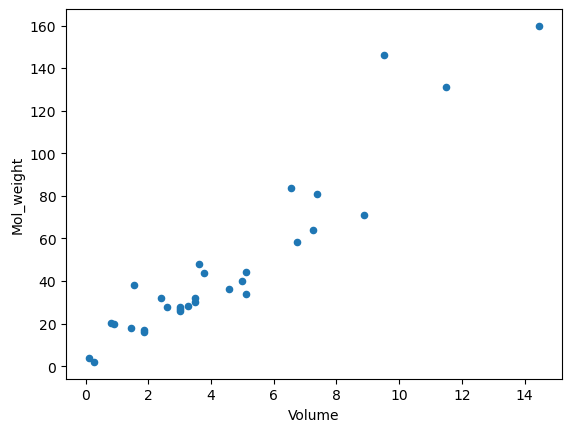

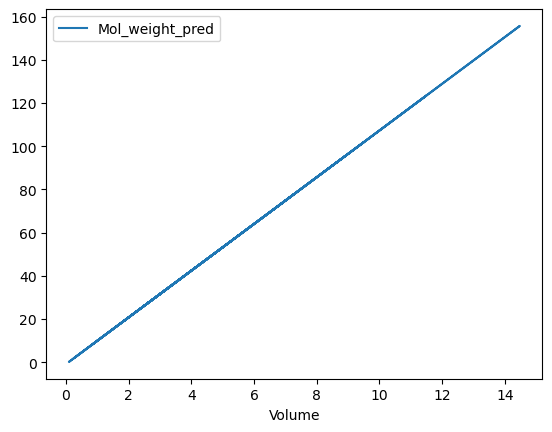

In [20]:
df.plot(x="Volume", y="Mol_weight", kind="scatter")
df.plot(x="Volume", y="Mol_weight_pred", kind="line")

<Axes: xlabel='Volume', ylabel='Mol_weight'>

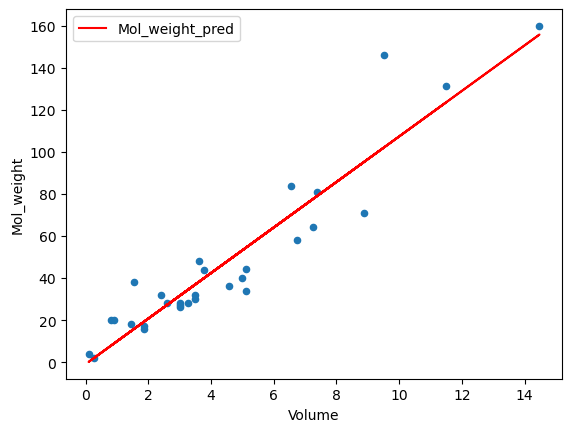

In [26]:
import matplotlib.pyplot as plt

_, ax = plt.subplots(1, 1)
df.plot(x="Volume", y="Mol_weight", kind="scatter", ax=ax)
df.plot(x="Volume", y="Mol_weight_pred", ax=ax, color="red")

<Axes: xlabel='Volume'>

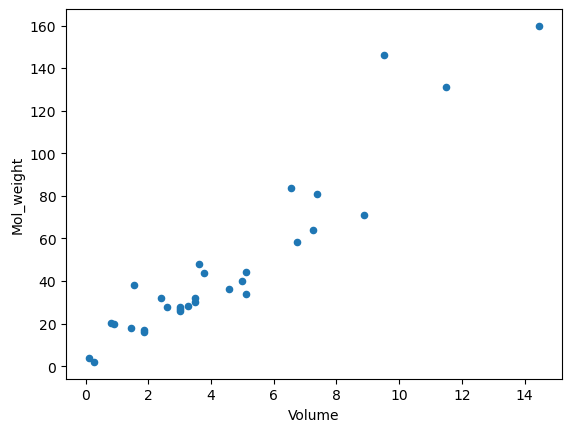

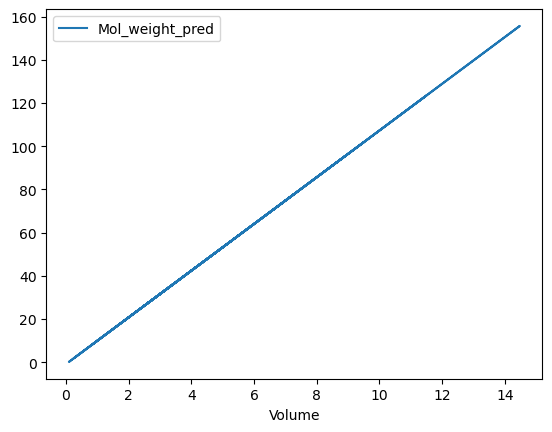